In [ ]:
# 0.prepare necessary libs
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds



In [ ]:
# 1.Construct dataset from tfds
(train, validation, test), info = tfds.load(
    'mnist',
    split=['train[:90%]', 'train[90%:]', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)
#MNIST
#├── train(54K)+validation(6K) = 60K
#└── test  = 10K
#              ↓
#          total = 70K


In [21]:
#2.Preprocessing the datasets(training and tests)

#convert image type from uint to float32 and normalize it in the range of [0,1]
def normalize_img(image, label):
 return tf.cast(image, tf.float32) / 255., label



In [22]:
# 3. Prepare datasets
batch_size=128
shuffle_buffer_size = int(info.splits['train'].num_examples * 0.9)
def prepare_dataset(ds, shuffle=False, shuffle_buffer_size=None):
    ds = ds.map(
        normalize_img,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.cache()

    if shuffle:
        ds = ds.shuffle(shuffle_buffer_size)

    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds
#apply to train/validation/test ds
train = prepare_dataset(
    train,
    shuffle=True,
    shuffle_buffer_size=shuffle_buffer_size
)

validation = prepare_dataset(validation)

test = prepare_dataset(test)

Number: 8



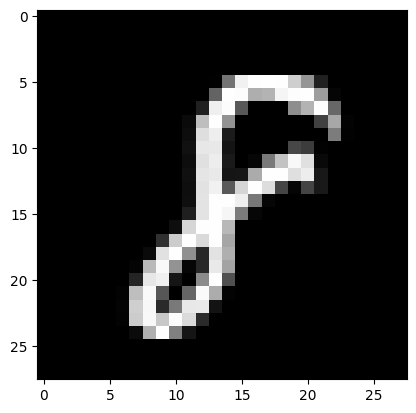

In [23]:
# data visualization of a random inputtaken 2 batches
for example in train.take(2):
    image, label = example[0], example[1]
x = np.random.randint(0, len(image))
print(f"Number: {int(label[x])}\n")
plt.imshow(image[x], cmap='gray')
plt.show()    

In [18]:
from keras import Sequential
from keras.layers import Conv2D, Dense, MaxPooling2D, Dropout
from keras.callbacks import EarlyStopping

In [ ]:
earlystopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

num_classes = 10

model = tf.keras.models.Sequential([
    
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(strides=(2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes)
])

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(epsilon=1e-8),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

In [26]:

model.fit(
    train,
    validation_data=validation,
    epochs=10,
    callbacks=[earlystopping]
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 158ms/step - loss: 0.2705 - sparse_categorical_accuracy: 0.9146 - val_loss: 0.0627 - val_sparse_categorical_accuracy: 0.9807
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 75s 177ms/step - loss: 0.0832 - sparse_categorical_accuracy: 0.9759 - val_loss: 0.0446 - val_sparse_categorical_accuracy: 0.9858
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 180ms/step - loss: 0.0589 - sparse_categorical_accuracy: 0.9824 - val_loss: 0.0368 - val_sparse_categorical_accuracy: 0.9893
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 75s 178ms/step - loss: 0.0492 - sparse_categorical_accuracy: 0.9863 - val_loss: 0.0373 - val_sparse_categorical_accuracy: 0.9893
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 181ms/step - loss: 0.0417 - sparse_categorical_accuracy: 0.9883 - val_loss: 0.0276 - val_sparse_categorical_accuracy: 0.9907
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 76s 179ms/step - loss: 0.0360 - sparse_categorical_accuracy: 0.9893 - val_loss: 0.0265 - val_sparse_categorical_acc

In [27]:
test_loss, test_accuracy = model.evaluate(test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0173 - sparse_categorical_accuracy: 0.9952
Test loss: 0.017290575429797173
Test accuracy: 0.995199978351593
